## Quick hands-on Dask

### What you need

- Install Graphviz (see https://graphviz.org/download/)
- Add some libraries to your Python distribution:
    - pip install distributed
    - pip install bokeh
    - pip install graphviz
    - pip install pandas
    - pip install dask

### Step 1

- Create a simple dataset with Pandas listing 50 products with an ID and a price for a given supermarket
- Duplicate this dataset (same list of 50 products) but with the prices of another supermarket
- Repeat this 20 times
- Compute the average price for each product, each supermarket, and the global average price of all products in both the Pandas and Dask style
- Increase all prices by 1.5%, the new price being stored in a new column
- At each step, take time to visualize the task graph

### Step 2

- Find, for your specific laptop, starting from how many records, computing the global average price becomes faster with Dask compared to Pandas.
- We'll assume a local cluster of n workers for all computations, n varying between 4 and the number of CPUs on your laptop.



In [43]:
import random
import time
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os
import dask.dataframe as dd
from dask.distributed import Client, LocalCluster

random.seed(27)

# Step 1 

## Data generating process

I start by generating one simple starting dataset, where I take product prices between 1 and 20 euros and round everything to the nearest cent. Next, I use the previously generated dataset to construct new ones. Again, we round everything to the nearest cent and make sure that prices do not fall below 1 euro. Because I also want to analyse the loading capabilities of Pandas and Dask, I save everything to a csv file instead of putting everything in a list.

In [2]:
# Our initial supermarket
def init_supermarket(no_products):
    product_ids = range(no_products)
    product_prices = [round(random.uniform(1,20), 2) for i in range(no_products)] # Product prices rounded to the nearest cent
    supermarket_data_init = pd.DataFrame({
        'Supermarket ID': 0,
        'Product ID': product_ids,
        'Price': product_prices
    })
    return supermarket_data_init

# Specify how we evolve the supermarket prices
def evolve_supermarket(supermarket_df):
    # Generate new prices, with a minimum price of 1 euro.
    product_prices_updated = [round(max(1, supermarket_df['Price'][i]+random.uniform(-2,2)), 2) for i in range(len(supermarket_df))]
    new_supermarket_df = {
        'Supermarket ID': supermarket_df['Supermarket ID'] + 1,
        'Product ID': supermarket_df['Product ID'],
        'Price': product_prices_updated,
    }
    return(new_supermarket_df)

# Generate the full dataset
def generate_data(no_supermarkets, no_products):
    # Save the first dataframe
    df_supermarket_next = init_supermarket(no_products)
    df_supermarket_next.to_csv('supermarkets0.csv', index=False)

    # Construct and save the evolved dataframes
    for i in range(1, no_supermarkets):
        df_supermarket_next = pd.DataFrame(evolve_supermarket(df_supermarket_next))
        df_supermarket_next.to_csv('supermarkets'+str(i)+'.csv', index=False)


no_supermarkets = 20 # Number of supermarkets
no_products = 50 # Number of products
generate_data(no_supermarkets, no_products)

## Pandas

I begin by analysing the loading capabilities of pandas. I will repeat each operation 100 times to accurately compare the loading and computation times of Pandas and Dask.

In [3]:
def pandas_load(filenames):
    dfs = []
    for fn in filenames:
        df = pd.read_csv(fn)
        dfs.append(df)

    return pd.concat(dfs, ignore_index=True)                       

no_repeats = 100
filenames = ['supermarkets'+str(i)+'.csv' for i in range(no_supermarkets)]
pandas_loading_times = np.zeros(no_repeats)

# Repeat the loading procedure multiple times for more accurate results
for i in range(no_repeats):
    loading_start_time = time.time()
    pandas_df = pandas_load(filenames)
    loading_end_time = time.time()
    pandas_loading_times[i] = (loading_end_time-loading_start_time)*1000

print(pandas_df.head())
print (F"Average loading time: {pandas_loading_times.mean():,.2f} ms.")

   Supermarket ID  Product ID  Price
0               0           0  13.32
1               0           1  14.33
2               0           2  19.18
3               0           3   4.73
4               0           4   2.24
Average loading time: 16.32 ms.


Then I analyse the computing capabilities of pandas.

In [4]:
def pandas_compute(pandas_df):
    # Compute mean across products and supermarkets, as well as the global mean (all rounded to nearest cent)
    avg_by_product = pandas_df.groupby('Product ID')['Price'].mean().round(2)
    avg_by_market = pandas_df.groupby('Supermarket ID')['Price'].mean().round(2)
    global_avg = pandas_df['Price'].mean().round(2)

    # Increase the prices of the products by 1.5%, and round to the nearest cent.
    # Note I create a copy of the original dataframe, to ensure the original dataframe stays unmodified.
    pandas_df_new = pandas_df.assign(Increased_Price=(pandas_df["Price"] * 1.015).round(2))

    return avg_by_product, avg_by_market, global_avg, pandas_df_new

pandas_computing_times = np.zeros(no_repeats)

for i in range(no_repeats):
    # Perform calculations
    computing_start_time = time.time()
    avg_by_product, avg_by_market, global_avg, pandas_df_result = pandas_compute(pandas_df)
    computing_end_time = time.time()
    pandas_computing_times[i] = (computing_end_time-computing_start_time)*1000

# Printing the output
print("Sample of DataFrame (after price increase)")
print(pandas_df_result.head().to_string(index=False))

print(f"Average prices per product:\n{avg_by_product.head()}\n")
print(f"Average prices per supermarket:\n{avg_by_market.head()}\n")
print(f"Global average price: €{global_avg:.2f}")

print(f"\nAverage computation time: {pandas_computing_times.mean():,.2f} ms")

Sample of DataFrame (after price increase)
 Supermarket ID  Product ID  Price  Increased_Price
              0           0  13.32            13.52
              0           1  14.33            14.54
              0           2  19.18            19.47
              0           3   4.73             4.80
              0           4   2.24             2.27
Average prices per product:
Product ID
0    14.88
1    15.32
2    19.79
3     6.97
4     2.14
Name: Price, dtype: float64

Average prices per supermarket:
Supermarket ID
0    11.18
1    11.06
2    11.15
3    11.39
4    11.39
Name: Price, dtype: float64

Global average price: €12.15

Average computation time: 1.20 ms


## Dask

Next, I analyse the loading capabilities of Dask

In [5]:
# Starting the cluster
client = Client(n_workers=os.cpu_count())
client

Connection method: Cluster object,Cluster type: distributed.LocalCluster
Dashboard: http://127.0.0.1:8787/status,
Dashboard: http://127.0.0.1:8787/status,Workers: 22
Total threads: 22,Total memory: 30.80 GiB
Status: running,Using processes: True
Comm: tcp://127.0.0.1:37699,Workers: 0
Dashboard: http://127.0.0.1:8787/status,Total threads: 0
Started: Just now,Total memory: 0 B
Comm: tcp://127.0.0.1:45827,Total threads: 1
Dashboard: http://127.0.0.1:35671/status,Memory: 1.40 GiB
Nanny: tcp://127.0.0.1:42589,


2025-10-24 19:29:18,411 - distributed.shuffle._scheduler_plugin - WARNING - Shuffle 08eb00f5d6c0337f812a568650d6b66f initialized by task ('shuffle-transfer-08eb00f5d6c0337f812a568650d6b66f', 18) executed on worker tcp://127.0.0.1:32801
2025-10-24 19:29:19,745 - distributed.shuffle._scheduler_plugin - WARNING - Shuffle 08eb00f5d6c0337f812a568650d6b66f deactivated due to stimulus 'task-finished-1761326959.7439678'
2025-10-24 19:29:19,949 - distributed.shuffle._scheduler_plugin - WARNING - Shuffle bcfb25ab97133d54760f8028bc5a9b05 initialized by task ('shuffle-transfer-bcfb25ab97133d54760f8028bc5a9b05', 7) executed on worker tcp://127.0.0.1:46033
2025-10-24 19:29:20,106 - distributed.shuffle._scheduler_plugin - WARNING - Shuffle bcfb25ab97133d54760f8028bc5a9b05 deactivated due to stimulus 'task-finished-1761326960.1039865'
2025-10-24 19:29:20,693 - distributed.shuffle._scheduler_plugin - WARNING - Shuffle 08eb00f5d6c0337f812a568650d6b66f initialized by task ('shuffle-transfer-08eb00f5d6c03

In [6]:
dask_loading_times = np.zeros(no_repeats)

# Repeat loading procedure multiple times for more accurate results
for i in range(no_repeats):
    loading_start_time = time.time()
    dask_df = dd.read_csv(filenames)
    loading_end_time = time.time()
    dask_loading_times[i]= (loading_end_time-loading_start_time)*1000                          

print(dask_df.head())
print (F"Average loading time: {dask_loading_times.mean():,.2f} ms.")

   Supermarket ID  Product ID  Price
0               0           0  13.32
1               0           1  14.33
2               0           2  19.18
3               0           3   4.73
4               0           4   2.24
Average loading time: 11.19 ms.


Then I analyse the computing capabilities of Dask

In [7]:
def dask_compute(dask_df):
    # Compute mean across products and supermarkets, as well as the global mean (all rounded to nearest cent)
    avg_by_product = dask_df.groupby('Product ID')['Price'].mean().round(2)
    avg_by_market = dask_df.groupby('Supermarket ID')['Price'].mean().round(2)
    global_avg = dask_df['Price'].mean().round(2)

    # Increase the prices of the products by 1.5%, and round to the nearest cent
    # Note I create a copy of the original dataframe, to ensure the original dataframe stays unmodified.
    add_column = dask_df.assign(Increased_Price=(dask_df["Price"] * 1.015).round(2))

    # Perform the actual computations
    avg_by_product_result = avg_by_product.compute()
    avg_by_market_result = avg_by_market.compute()
    global_avg_result = global_avg.compute()
    dask_df_result = add_column.compute()

    return avg_by_product_result, avg_by_market_result, global_avg_result, dask_df_result

no_repeats = 2
dask_computing_times = np.zeros(no_repeats)
for i in range(no_repeats):
    # Perform calculations
    computing_start_time = time.time()
    avg_by_product_result, avg_by_market_result, global_avg_result, dask_df_result = dask_compute(dask_df)
    computing_end_time = time.time()
    dask_computing_times[i] = (computing_end_time-computing_start_time)*1000

# Printing the output
print("Sample of DataFrame (after price increase)")
print(dask_df_result.head())

print(f"Average prices per product:\n{avg_by_product_result.head()}\n")
print(f"Average prices per supermarket:\n{avg_by_market_result.head()}\n")
print(f"Global average price: €{global_avg_result:.2f}")

print(f"\nAverage computation time: {dask_computing_times.mean():,.2f} ms")



Sample of DataFrame (after price increase)
   Supermarket ID  Product ID  Price  Increased_Price
0               0           0  13.32            13.52
1               0           1  14.33            14.54
2               0           2  19.18            19.47
3               0           3   4.73             4.80
4               0           4   2.24             2.27
Average prices per product:
Product ID
2     19.79
3      6.97
7     12.63
12     4.22
13    20.47
Name: Price, dtype: float64

Average prices per supermarket:
Supermarket ID
2     11.15
3     11.39
7     11.88
12    12.50
13    12.61
Name: Price, dtype: float64

Global average price: €12.15

Average computation time: 1,647.92 ms


In [8]:
# Stop the client
client.close()

## Performance Comparison: Pandas vs Dask
Analysing the performance of Pandas vs Dask, I see that Dask is slightly faster at loading. However, it is significantly slower at computing, which is a result of the significant overhead that Dask has by having to create multiple parallel sessions. For data of this size, I see that Pandas is the preferred choice as the total run times are the lowest. In the next part I will see if this is still the case if we increase the amount of files and the data size.


In [9]:
summary_df = pd.DataFrame({
    "Pandas - Load": pd.Series(pandas_loading_times).describe(),
    "Dask - Load": pd.Series(dask_loading_times).describe(),
    "Pandas - Compute": pd.Series(pandas_computing_times).describe(),
    "Dask - Compute": pd.Series(dask_computing_times).describe(),
}).round(2)

display(summary_df)


,Pandas - Load,Dask - Load,Pandas - Compute,Dask - Compute
count,100.00,100.00,100.00,2.00
mean,16.32,11.19,1.20,1647.92
std,1.68,15.55,0.24,866.95
min,15.34,7.15,1.11,1034.89
25%,15.53,8.77,1.14,1341.41
50%,15.68,9.23,1.16,1647.92
75%,15.97,10.23,1.20,1954.43
max,22.84,163.75,3.49,2260.94


# Step 2

For this part I will analyse when Dask will outperform Pandas for the global average computation, when increasing the number of supermarkets or the number of products.


In [10]:
client = Client(n_workers = os.cpu_count())
client

Connection method: Cluster object,Cluster type: distributed.LocalCluster
Dashboard: http://127.0.0.1:8787/status,
Dashboard: http://127.0.0.1:8787/status,Workers: 22
Total threads: 22,Total memory: 30.80 GiB
Status: running,Using processes: True
Comm: tcp://127.0.0.1:39463,Workers: 0
Dashboard: http://127.0.0.1:8787/status,Total threads: 0
Started: Just now,Total memory: 0 B
Comm: tcp://127.0.0.1:45403,Total threads: 1
Dashboard: http://127.0.0.1:45989/status,Memory: 1.40 GiB
Nanny: tcp://127.0.0.1:34655,


# Increasing the number of supermarkets

I begin by looking at for which number of supermarkets Dask outperforms Pandas, while keeping the number of products the same. The following runs the code for the analysis.

In [ ]:
no_supermarkets = 1000 # Maximum number of supermarkets
no_products = 50 # Number of products

# Generate the data with the new parameters
generate_data(no_supermarkets, no_products)

# Construct the grid
stepsize = 50
grid = np.arange(stepsize, no_supermarkets+1, stepsize, dtype='int')
no_grid = len(grid)

pandas_loading_times = np.zeros(no_grid)
pandas_computing_times = np.zeros(no_grid)
dask_loading_times = np.zeros(no_grid)
dask_computing_times = np.zeros(no_grid)

for i, x in enumerate(grid):
    filenames = ['supermarkets'+str(j)+'.csv' for j in range(x)]

    # Pandas
    pandas_sl = time.time()
    pandas_df = pandas_load(filenames)
    pandas_el = time.time()
    pandas_loading_times[i]= (pandas_el - pandas_sl) * 1000

    pandas_sc = time.time()
    pandas_global_avg = pandas_df['Price'].mean()
    pandas_ec = time.time()
    pandas_computing_times[i] = (pandas_ec - pandas_sc) * 1000

    # Dask
    dask_sl = time.time()
    dask_df = dd.read_csv(filenames)
    dask_el = time.time()
    dask_loading_times[i]= (dask_el - dask_sl) * 1000

    dask_sc = time.time()
    dask_global_avg = dask_df['Price'].mean().compute()
    dask_ec = time.time()
    dask_computing_times[i] = (dask_ec - dask_sc) * 1000


In [ ]:
# Define a plot function to compare results
def plot_benchmark(grid, pandas_loading_times, pandas_computing_times, dask_loading_times, dask_computing_times, varying="Supermarkets"):
    # Compute total run times for dask and pandas
    pandas_total = np.asarray(pandas_loading_times) + np.asarray(pandas_computing_times)
    dask_total   = np.asarray(dask_loading_times)   + np.asarray(dask_computing_times)
    xlabel = "# " + varying

    # Construct the line plots
    fig, axes = plt.subplots(1, 3, figsize=(15, 4), sharex=True)
    panels = [
        ("Loading time (ms)", pandas_loading_times, dask_loading_times),
        ("Computation time (ms)", pandas_computing_times, dask_computing_times),
        ("Total time (ms)", pandas_total, dask_total),
    ]

    for ax, (title, y_pd, y_dk) in zip(axes, panels):
        ax.plot(grid, y_pd, marker="o", label="Pandas")
        ax.plot(grid, y_dk, marker="s", label="Dask")
        ax.set_title(title)
        ax.set_xlabel(xlabel)
        ax.set_ylabel("ms")
        ax.grid(True, linestyle="--", alpha=0.6)
        ax.legend()

    plt.tight_layout()
    plt.show()

    # Construct the scatter plots
    fig, axes = plt.subplots(1, 3, figsize=(15, 4))
    pairs = [
        ("Loading time (ms)", np.asarray(pandas_loading_times), np.asarray(dask_loading_times)),
        ("Computation time (ms)", np.asarray(pandas_computing_times), np.asarray(dask_computing_times)),
        ("Total time (ms)", pandas_total, dask_total),
    ]

    for ax, (title, x_pd, y_dk) in zip(axes, pairs):
        ax.scatter(x_pd, y_dk, s=30)
        lim_max = max(x_pd.max(), y_dk.max()) * 1.05
        ax.plot([0, lim_max], [0, lim_max], linestyle="--", alpha=0.7)  # y=x
        ax.set_xlim(0, lim_max)
        ax.set_ylim(0, lim_max)
        ax.set_xlabel("Pandas (ms)")
        ax.set_ylabel("Dask (ms)")
        ax.set_title(title)
        ax.grid(True, linestyle="--", alpha=0.6)

    plt.tight_layout()
    plt.show()

I plot the results, comparing the loading times, computing times and the total run time. We can see that Dask is faster in loading than Pandas across the whole grid. On the other hand, Pandas is faster in computing than Dask across the whole grid. The difference between the two increases when we increase the amount of supermarkets (or files). In general, we see that Pandas has a faster total run time than Dask, which comes somewhat as a surprise. However, it should be noted that the files are all very small and that the mean function is a very lightweight function which is easy to compute. This makes the parallel computing power of Dask less beneficial. We further investigate this in the next part.


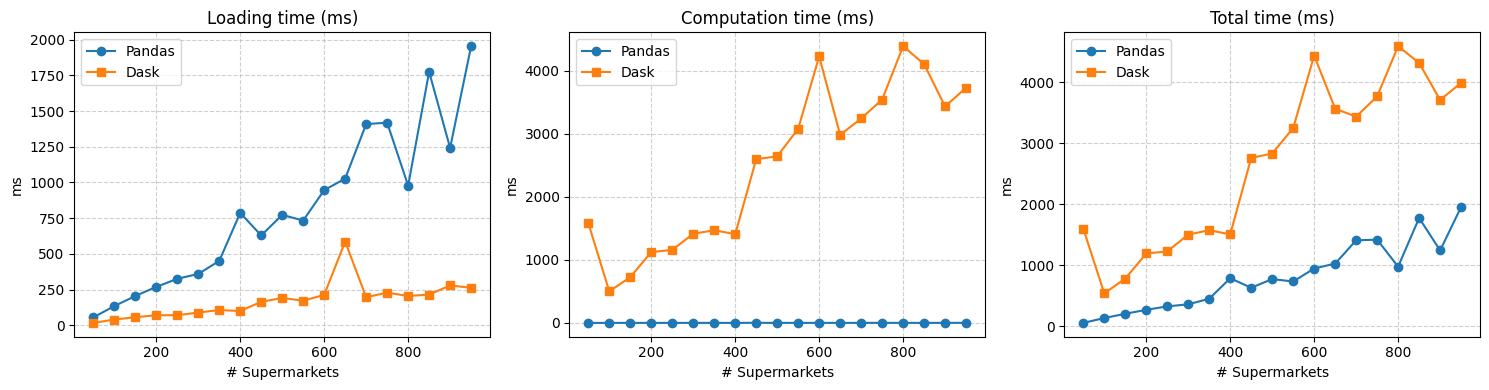

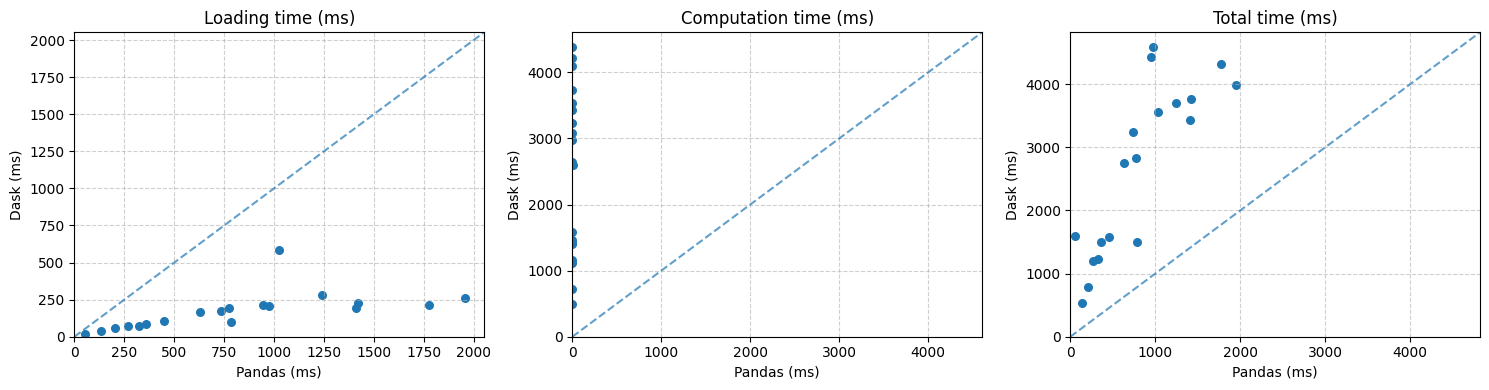

In [21]:
plot_benchmark(grid, pandas_loading_times, pandas_computing_times, dask_loading_times, dask_computing_times, varying="Supermarkets")

We repeat the previous experiment, but now instead of the mean function we use a much more complicated function which groups the variables and computes some summary statistics.

In [22]:
# Construct the grid
stepsize = 50
grid = np.arange(stepsize, no_supermarkets+1, stepsize, dtype='int')
no_grid = len(grid)

pandas_loading_times = np.zeros(no_grid)
pandas_computing_times = np.zeros(no_grid)
dask_loading_times = np.zeros(no_grid)
dask_computing_times = np.zeros(no_grid)

for i, x in enumerate(grid):
    filenames = ['supermarkets'+str(j)+'.csv' for j in range(x)]

    # Pandas
    pandas_sl = time.time()
    pandas_df = pandas_load(filenames)
    pandas_el = time.time()
    pandas_loading_times[i]= (pandas_el - pandas_sl) * 1000

    pandas_sc = time.time()
    pandas_result = pandas_df.groupby('Supermarket ID')['Price'].agg(['mean', 'std', 'min', 'max'])
    pandas_ec = time.time()
    pandas_computing_times[i] = (pandas_ec - pandas_sc) * 1000

    # Dask
    dask_sl = time.time()
    dask_df = dd.read_csv(filenames)
    dask_el = time.time()
    dask_loading_times[i]= (dask_el - dask_sl) * 1000

    dask_sc = time.time()
    dask_result = dask_df.groupby('Supermarket ID')['Price'].agg(['mean', 'std', 'min', 'max']).compute()
    dask_ec = time.time()
    dask_computing_times[i] = (dask_ec - dask_sc) * 1000


Plotting the results again, we see that this has not done much for the difference between Dask and Pandas. All that is left now is to analyse what will happen if the number of products increases, such that the individual file sizes are now much larger.

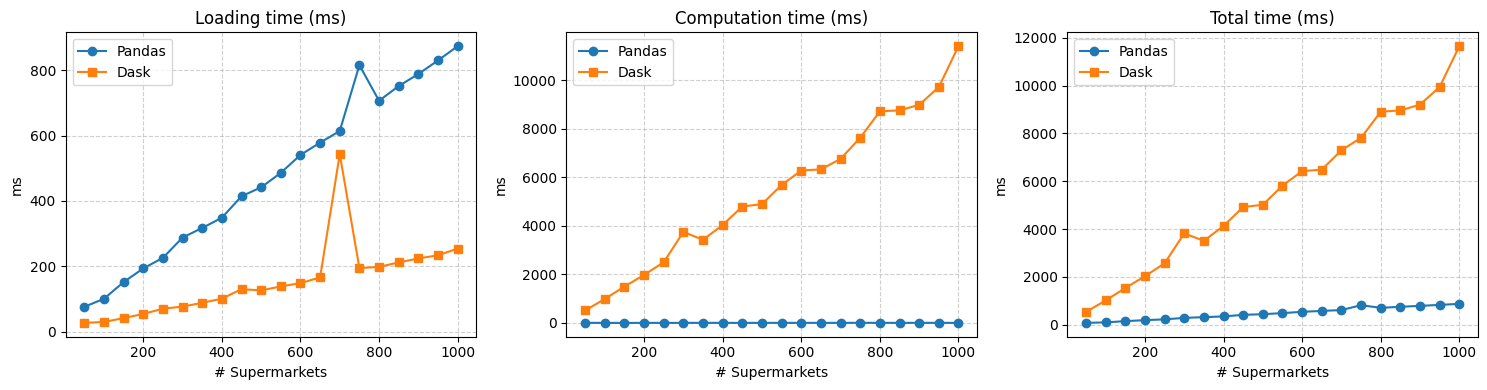

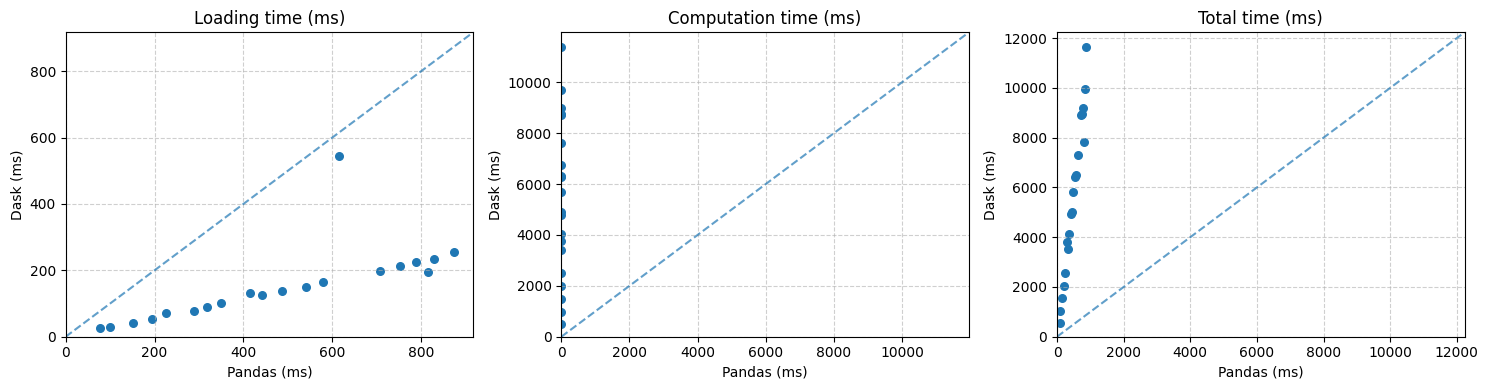

In [23]:
plot_benchmark(grid, pandas_loading_times, pandas_computing_times, dask_loading_times, dask_computing_times, varying="Supermarkets")

## Increasing the number of products

I do the same analysis as before, but now keep the number of supermarkets constant while increasing the number of products. I set the number of supermarkets equal to 50.

In [24]:
no_supermarkets = 50 # Number of supermarkets
no_products = 100000 # Maximum number of products


filenames = ['supermarkets'+str(j)+'.csv' for j in range(no_supermarkets)]

# Construct the grid
stepsize = 5000
grid = np.arange(stepsize, no_products+1, stepsize, dtype='int')
no_grid = len(grid)

pandas_loading_times = np.zeros(no_grid)
pandas_computing_times = np.zeros(no_grid)
dask_loading_times = np.zeros(no_grid)
dask_computing_times = np.zeros(no_grid)

for i, x in enumerate(grid):
    # Generate the data with the new parameters
    generate_data(no_supermarkets, x)

    # Pandas
    pandas_sl = time.time()
    pandas_df = pandas_load(filenames)
    pandas_el = time.time()
    pandas_loading_times[i]= (pandas_el - pandas_sl) * 1000

    pandas_sc = time.time()
    pandas_global_avg = pandas_df['Price'].mean()
    pandas_ec = time.time()
    pandas_computing_times[i] = (pandas_ec - pandas_sc) * 1000

    # Dask
    dask_sl = time.time()
    dask_df = dd.read_csv(filenames)
    dask_el = time.time()
    dask_loading_times[i]= (dask_el - dask_sl) * 1000

    dask_sc = time.time()
    dask_global_avg = dask_df['Price'].mean().compute()
    dask_ec = time.time()
    dask_computing_times[i] = (dask_ec - dask_sc) * 1000


I plot the results again. We see the same story as before: Dask is faster in loading the data and Pandas is faster in the computation. However, since te loading of files now takes significantly more time, we see that as we increase the number of products Pandas and Dask get closer in total computation times. Dask outperfroms Pandas in total computation times when we go above 30.000 products.

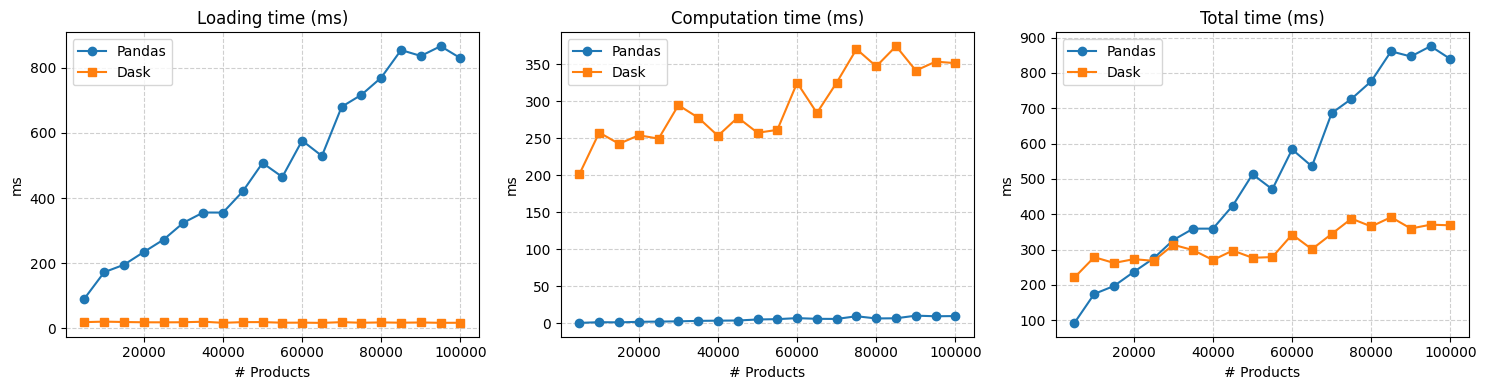

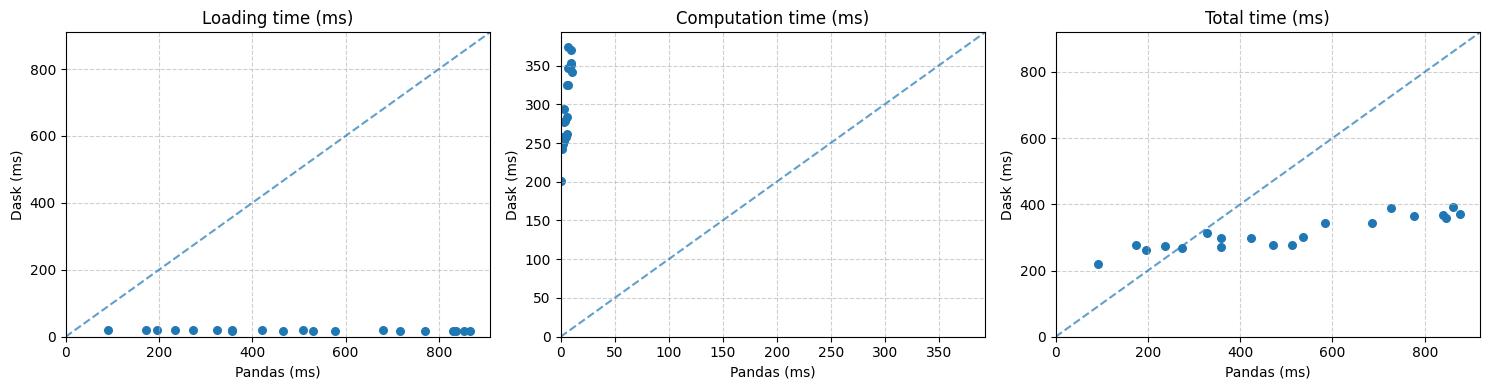

In [25]:
plot_benchmark(grid, pandas_loading_times, pandas_computing_times, dask_loading_times, dask_computing_times, varying="Products")

## Increasing the number of products and supermarkets simultaneously

I now repeat the previous experiments again, but increase both the number of products and supermarkets simultaneously. To do this, I use a 5x5 grid of values.

In [26]:
no_supermarkets_grid = np.array([100, 200, 300, 400, 500])
no_products_grid = np.array([10000, 20000, 30000, 40000, 50000])

pandas_loading_times = np.zeros((len(no_supermarkets_grid), len(no_products_grid)))
pandas_computing_times = np.zeros((len(no_supermarkets_grid), len(no_products_grid)))
dask_loading_times = np.zeros((len(no_supermarkets_grid), len(no_products_grid)))
dask_computing_times = np.zeros((len(no_supermarkets_grid), len(no_products_grid)))

for j, no_products in enumerate(no_products_grid):
    generate_data(no_supermarkets_grid.max(), no_products)
    for i, no_supermarkets in enumerate(no_supermarkets_grid):
        filenames = ['supermarkets'+str(k)+'.csv' for k in range(no_supermarkets)]

        pandas_sl = time.time()
        pandas_df = pandas_load(filenames)
        pandas_el = time.time()
        pandas_loading_times[i, j] = (pandas_el - pandas_sl) * 1000

        pandas_sc = time.time()
        pandas_global_avg = pandas_df['Price'].mean()
        pandas_ec = time.time()
        pandas_computing_times[i, j] = (pandas_ec - pandas_sc) * 1000

        dask_sl = time.time()
        dask_df = dd.read_csv(filenames)
        dask_el = time.time()
        dask_loading_times[i, j] = (dask_el - dask_sl) * 1000

        dask_sc = time.time()
        dask_global_avg = dask_df['Price'].mean().compute()
        dask_ec = time.time()
        dask_computing_times[i, j] = (dask_ec - dask_sc) * 1000

In [39]:
def plot_benchmark_rows(no_supermarkets_grid, no_products_grid,
                        pandas_loading_times, pandas_computing_times,
                        dask_loading_times, dask_computing_times):

    pandas_total = pandas_loading_times + pandas_computing_times
    dask_total   = dask_loading_times   + dask_computing_times

    fig, axes = plt.subplots(len(no_products_grid), 3,
                             figsize=(18, 16), sharex=True, sharey=True)

    panel_titles = ["Loading time (ms)", "Computation time (ms)", "Total time (ms)"]

    for i, no_products in enumerate(no_products_grid):
        for j, (pd_data, dk_data) in enumerate([
            (pandas_loading_times, dask_loading_times),
            (pandas_computing_times, dask_computing_times),
            (pandas_total, dask_total)
        ]):
            ax = axes[i, j]

            ax.plot(no_supermarkets_grid, pd_data[:, i],
                    marker='o', label='Pandas')
            ax.plot(no_supermarkets_grid, dk_data[:, i],
                    marker='s', label='Dask')

            ax.grid(True, linestyle="--", alpha=0.6)
            if i == 0:
                ax.set_title(panel_titles[j], fontsize=12)
            if i == len(no_products_grid) - 1:
                ax.set_xlabel("# Supermarkets")
            if j == 0:
                ax.set_ylabel(f"#Products = {no_products}")
            if i == 0 and j == 0:
                ax.legend(loc="upper left")

    fig.suptitle("Benchmark results across supermarkets and product sizes", fontsize=16)
    plt.tight_layout(rect=[0, 0, 1, 0.96])
    plt.show()

I plot the results below. We see that everywhere we again have that Pandas is better at computing and Dask at loading. It is very clear that as both the number of supermarkets and products increase, we should use Dask instead of Pandas. This is visible if we increase the number of products above 30.000, and for a larger number of supermarkets we see the difference in total run times increase.

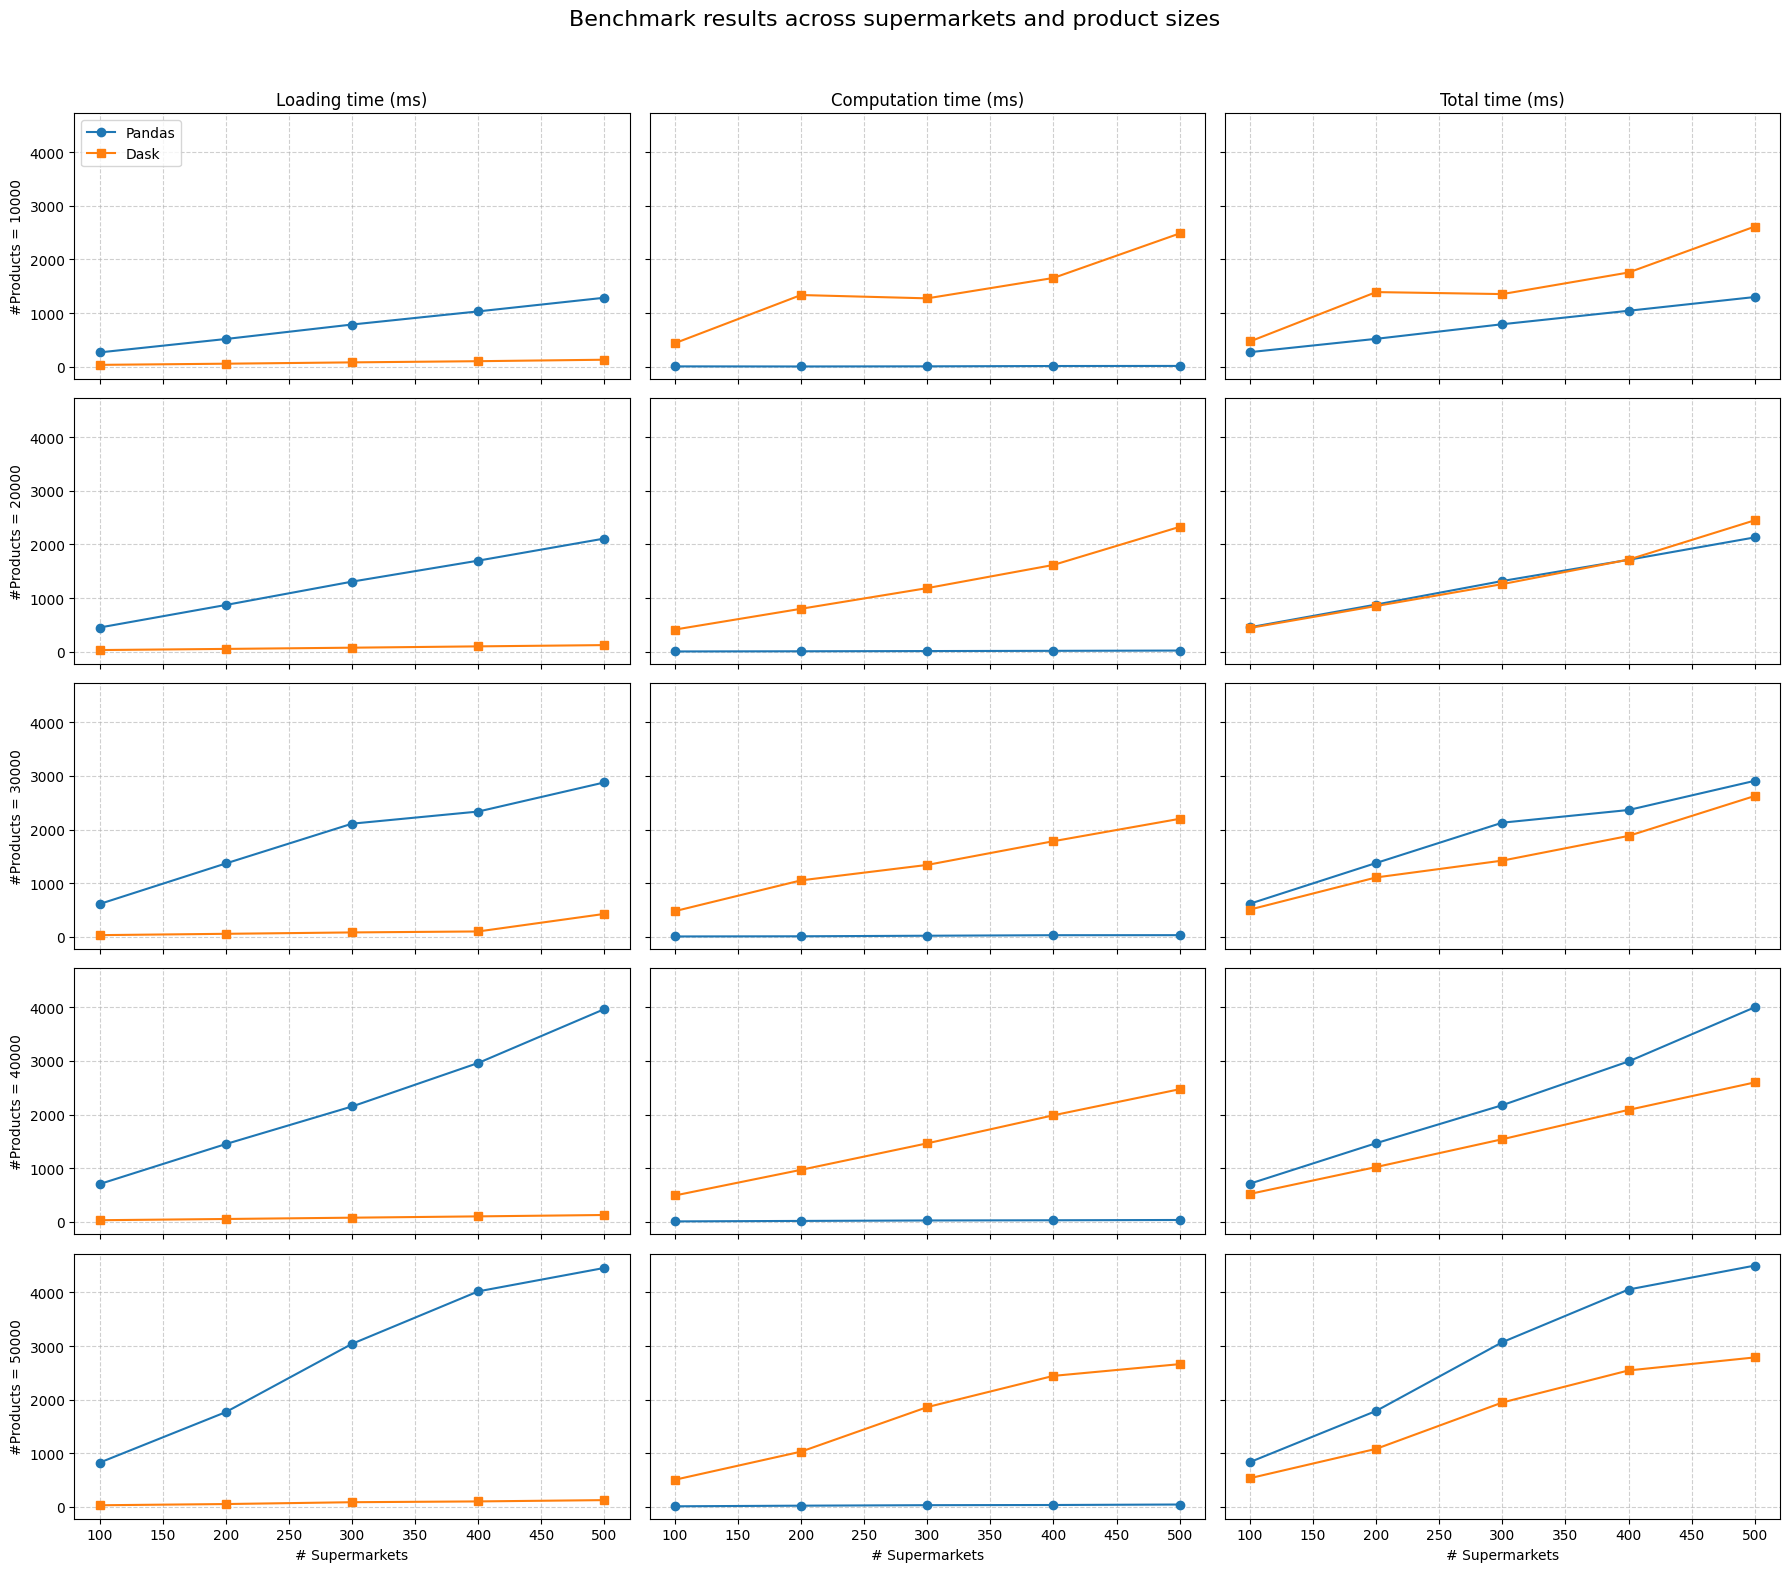

In [40]:
plot_benchmark_rows(no_supermarkets_grid, no_products_grid, pandas_loading_times, pandas_computing_times, dask_loading_times, dask_computing_times)

In [41]:
# Stop the client
client.close()

## Varying the number of workers available to Dask

I will now analyse what happens if we vary the number of workers that Dask can use. My laptop has 22 avaible cores, so I vary the amount of workers between 4 and 22, increasing by 2 at every step. I use 20.000 products with 500 supermarkets, as we saw in the previous parts that for these settings Dask (with 22 cores) and Pandas had comparable computation times.

In [47]:
no_products = 20000
no_supermarkets = 500
filenames = ['supermarkets'+str(j)+'.csv' for j in range(no_supermarkets)]

# Generate the data once for this experiment
generate_data(no_supermarkets, no_products)

# Worker grid
worker_grid = np.arange(4, 23, 2)

# Storage
pandas_loading_times = np.zeros(len(worker_grid))
pandas_computing_times = np.zeros(len(worker_grid))
dask_loading_times = np.zeros(len(worker_grid))
dask_computing_times = np.zeros(len(worker_grid))

# Pandas baseline (single-core)
pandas_sl = time.time()
pandas_df = pandas_load(filenames)
pandas_el = time.time()
pandas_loading_times[:] = (pandas_el - pandas_sl) * 1000  # same for all, for comparison

pandas_sc = time.time()
pandas_global_avg = pandas_df['Price'].mean()
pandas_ec = time.time()
pandas_computing_times[:] = (pandas_ec - pandas_sc) * 1000

for i, n_workers in enumerate(worker_grid):
    # Loading
    dask_sl = time.time()
    dask_df = dd.read_csv(filenames)
    dask_el = time.time()
    dask_loading_times[i] = (dask_el - dask_sl) * 1000

    # Computation
    dask_sc = time.time()
    dask_global_avg = dask_df['Price'].mean().compute(n_workers=n_workers)
    dask_ec = time.time()
    dask_computing_times[i] = (dask_ec - dask_sc) * 1000


When plotting the results, we see no real difference when we increase the number of workers for both the loading and computation times. 

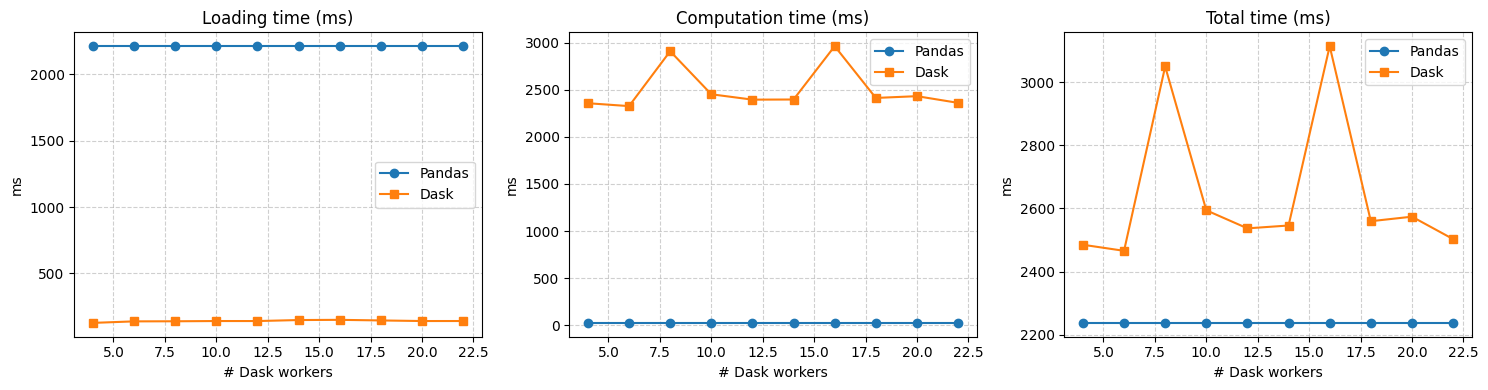

In [48]:
# Plot results
pandas_total = pandas_loading_times + pandas_computing_times
dask_total = dask_loading_times + dask_computing_times

fig, axes = plt.subplots(1, 3, figsize=(15, 4), sharex=True)
titles = ["Loading time (ms)", "Computation time (ms)", "Total time (ms)"]

for ax, y_pd, y_dk, title in zip(
    axes,
    [pandas_loading_times, pandas_computing_times, pandas_total],
    [dask_loading_times, dask_computing_times, dask_total],
    titles,
):
    ax.plot(worker_grid, y_pd, marker='o', label='Pandas')
    ax.plot(worker_grid, y_dk, marker='s', label='Dask')
    ax.set_title(title)
    ax.set_xlabel("# Dask workers")
    ax.set_ylabel("ms")
    ax.grid(True, linestyle="--", alpha=0.6)
    ax.legend()

plt.tight_layout()
plt.show()